# **Name :- Anirudh Patekar**
# **Reg ID :- UST24R0101004**
# **CA1 Project of Deep Learning**
# Project Description :- This project develops a time-series forecasting system using an LSTM model to predict Carbon Monoxide (CO) concentration from the UCI Air Quality dataset. The data is preprocessed, converted into 24-hour sequences, and used to train and evaluate the model on unseen data.

In [2]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

# For reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# **Dataset: Air Quality Dataset**  
**Source:** UCI Machine Learning Repository  
**Application Area:** Air Quality Monitoring and Environmental Forecasting  

The dataset contains hourly measurements of air pollutants, gas sensor responses, temperature, and humidity. Important attributes include pollutant concentrations such as **CO(GT), NOx(GT), and NO2(GT)**, sensor measurements **PT08.S1–PT08.S5**, and environmental variables **T (Temperature), RH (Relative Humidity), and AH (Absolute Humidity)**.

In [3]:
!pip install ucimlrepo

from ucimlrepo import fetch_ucirepo

# fetch dataset
air_quality = fetch_ucirepo(id=360)

df = pd.DataFrame(air_quality.data.features)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   int64  
 4   NMHC(GT)       9357 non-null   int64  
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   int64  
 7   NOx(GT)        9357 non-null   int64  
 8   PT08.S3(NOx)   9357 non-null   int64  
 9   NO2(GT)        9357 non-null   int64  
 10  PT08.S4(NO2)   9357 non-null   int64  
 11  PT08.S5(O3)    9357 non-null   int64  
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(5), int64(8), object(2)
memory usage: 1.1+ MB


In [5]:
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,3/10/2004,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888


In [12]:
print("Dataset Shape:",df.shape)

print("\nNumber of Records:",df.shape[0])

print("\nNumber of Features:",df.shape[1])

print("\nFeature Names:",df.columns)

Dataset Shape: (9357, 15)

Number of Records: 9357

Number of Features: 15

Feature Names: Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH'],
      dtype='object')


In [16]:
print(df.describe())

            CO(GT)  PT08.S1(CO)     NMHC(GT)     C6H6(GT)  PT08.S2(NMHC)  \
count  9357.000000  9357.000000  9357.000000  9357.000000    9357.000000   
mean    -34.207524  1048.990061  -159.090093     1.865683     894.595276   
std      77.657170   329.832710   139.789093    41.380206     342.333252   
min    -200.000000  -200.000000  -200.000000  -200.000000    -200.000000   
25%       0.600000   921.000000  -200.000000     4.000000     711.000000   
50%       1.500000  1053.000000  -200.000000     7.900000     895.000000   
75%       2.600000  1221.000000  -200.000000    13.600000    1105.000000   
max      11.900000  2040.000000  1189.000000    63.700000    2214.000000   

           NOx(GT)  PT08.S3(NOx)      NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)  \
count  9357.000000   9357.000000  9357.000000   9357.000000  9357.000000   
mean    168.616971    794.990168    58.148873   1391.479641   975.072032   
std     257.433866    321.993552   126.940455    467.210125   456.938184   
min    -200

In [15]:
# Check how many values are represented as -200

missing_values = (df == -200).sum()

print("Number of -200 Values in Each Column:\n")

print(missing_values)

Number of -200 Values in Each Column:

Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64


# **Plotting the Dataset Before Preprocessing**

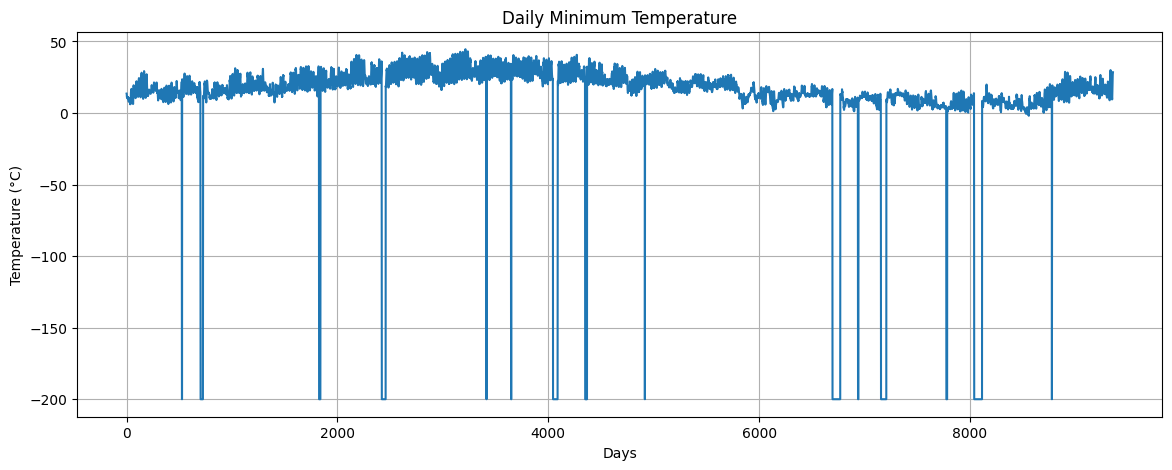

In [18]:
plt.figure(figsize=(14,5))
plt.plot(df['T'])
plt.title("Daily Minimum Temperature")
plt.xlabel("Days")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

# **Data Pre-processing**

#The Air Quality dataset was preprocessed by handling missing values, checking duplicates, standardizing Date and Time, and sorting the data chronologically. The required input features and target variable were selected, and numerical data was normalized for LSTM training.

In [19]:
# Replace -200 values with NaN

df.replace(-200, np.nan, inplace=True)

print("Missing Values After Replacing -200 with NaN:\n")

print(df.isnull().sum())

Missing Values After Replacing -200 with NaN:

Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64


In [20]:
# Check total missing values

print("Total Missing Values Before Handling:")

print(df.isnull().sum().sum())

Total Missing Values Before Handling:
16701


In [21]:
# Separate numeric columns

numeric_columns = df.select_dtypes(include=[np.number]).columns

# Fill missing values using linear interpolation

df[numeric_columns] = df[numeric_columns].interpolate(
    method='linear'
)

# Forward fill remaining missing values

df[numeric_columns] = df[numeric_columns].ffill()

# Backward fill any remaining missing values

df[numeric_columns] = df[numeric_columns].bfill()

print("Total Missing Values After Handling:")

print(df.isnull().sum().sum())

Total Missing Values After Handling:
0


In [24]:
# Check duplicate records

duplicate_count = df.duplicated().sum()

print("Number of Duplicate Records:", duplicate_count)

Number of Duplicate Records: 0


# **Time-Series Sequence Preparation**

#The data was converted into input-output sequences using a **24-hour time window**. The previous 24 observations are used as input to predict the **next CO(GT) value**.

In [36]:
# Clean Date and Time

df['Date'] = df['Date'].astype(str).str.strip()

df['Time'] = (
    df['Time']
    .astype(str)
    .str.strip()
    .str.replace('.', ':', regex=False)
)

# Create DateTime

df['DateTime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    dayfirst=True,
    errors='coerce'
)

print("Total Records:", len(df))
print("Invalid DateTime:", df['DateTime'].isnull().sum())

Total Records: 3597
Invalid DateTime: 0


In [37]:
df = df.sort_values('DateTime').reset_index(drop=True)

df[['Date', 'Time', 'DateTime']].head()

,Date,Time,DateTime
0,4/1/2004,0:00:00,2004-01-04 00:00:00
1,4/1/2004,1:00:00,2004-01-04 01:00:00
2,4/1/2004,2:00:00,2004-01-04 02:00:00
3,4/1/2004,3:00:00,2004-01-04 03:00:00
4,4/1/2004,4:00:00,2004-01-04 04:00:00


In [38]:
target_column = 'CO(GT)'

feature_columns = [
    'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
    'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)',
    'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)',
    'T', 'RH', 'AH'
]

model_df = df[['DateTime'] + feature_columns].copy()

print(model_df.shape)

(3597, 14)


# **Training and Testing Split**

#The dataset was divided chronologically into **70% training, 10% validation, and 20% testing data**. This ensures that past observations are used to predict future values, while the testing data remains completely unseen during model training.

In [43]:
total = len(model_df)

train_end = int(total * 0.70)
val_end = int(total * 0.80)

train_df = model_df.iloc[:train_end]
validation_df = model_df.iloc[train_end:val_end]
test_df = model_df.iloc[val_end:]

print("Training:", train_df.shape)
print("Validation:", validation_df.shape)
print("Testing:", test_df.shape)

Training: (2517, 14)
Validation: (360, 14)
Testing: (720, 14)


In [44]:
from sklearn.preprocessing import MinMaxScaler

# Create scalers
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

# Scale features
train_features = feature_scaler.fit_transform(
    train_df[feature_columns]
)

validation_features = feature_scaler.transform(
    validation_df[feature_columns]
)

test_features = feature_scaler.transform(
    test_df[feature_columns]
)

# Scale target
train_target = target_scaler.fit_transform(
    train_df[[target_column]]
)

validation_target = target_scaler.transform(
    validation_df[[target_column]]
)

test_target = target_scaler.transform(
    test_df[[target_column]]
)

In [45]:
def create_sequences(features, target, time_steps):

    X = []
    y = []

    for i in range(time_steps, len(features)):
        X.append(features[i-time_steps:i])
        y.append(target[i])

    return np.array(X), np.array(y)

In [47]:
TIME_STEPS = 24

X_train, y_train = create_sequences(
    train_features,
    train_target,
    TIME_STEPS
)

X_validation, y_validation = create_sequences(
    validation_features,
    validation_target,
    TIME_STEPS
)

X_test, y_test = create_sequences(
    test_features,
    test_target,
    TIME_STEPS
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nX_validation:", X_validation.shape)
print("y_validation:", y_validation.shape)

print("\nX_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (2493, 24, 13)
y_train: (2493, 1)

X_validation: (336, 24, 13)
y_validation: (336, 1)

X_test: (696, 24, 13)
y_test: (696, 1)


# **Model Implementation**

#An **LSTM model** was implemented with **13 input features**, two LSTM layers containing **64 and 32 recurrent units**, Dropout layers, and a single-neuron Dense output layer. The model uses the **Adam optimizer**, **Mean Squared Error (MSE) loss**, **50 epochs**, and a **batch size of 32**, with the model summary used to display the architecture and major layers.

In [50]:
# Model Implementation
model = Sequential()

model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

model.add(Dropout(0.2))
model.add(LSTM(32))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [51]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 24, 64)         │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,417 (126.63 KB)

 Trainable params: 32,417 (126.63 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# **Model Training and Validation**

In [53]:
history = model.fit(
    X_train,
    y_train,

    validation_data=(X_validation, y_validation),

    epochs=50,
    batch_size=32,

    callbacks=[early_stopping],

    verbose=1
)

Epoch 1/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 0.0239 - val_loss: 0.0150
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0164 - val_loss: 0.0127
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0145 - val_loss: 0.0144
Epoch 4/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0136 - val_loss: 0.0115
Epoch 5/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0117 - val_loss: 0.0098
Epoch 6/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0103 - val_loss: 0.0066
Epoch 7/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.0090 - val_loss: 0.0065
Epoch 8/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - loss: 0.0083 - val_loss: 0.0052
Epoch 9/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0080 - val_loss: 0.0057
Epoch 10/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0077 - val_loss: 0.0051
Epoch 11/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0075 - val_loss: 0.0057
Epoch 12/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - loss: 0.0

# **Plotting Training and Validation loss on axis**

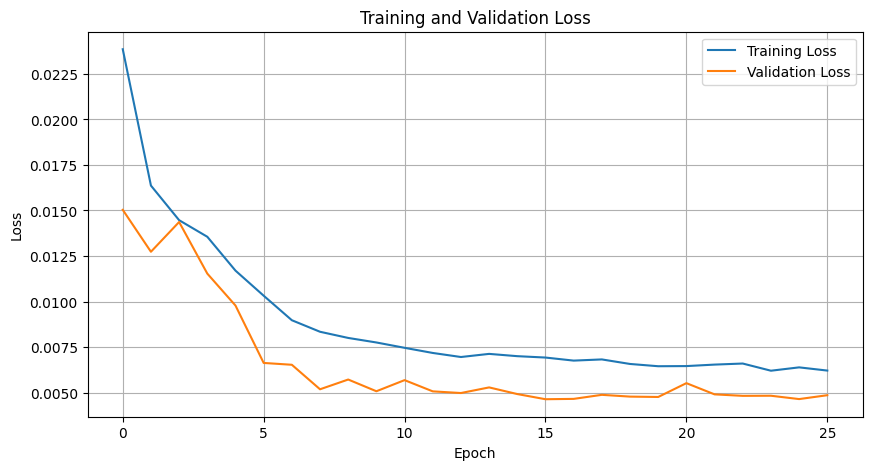

In [54]:
plt.figure(figsize=(10, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.grid()

plt.show()

# **Model Testing and making Predictions**

In [55]:
# Generate predictions
y_pred = model.predict(X_test)

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


In [56]:
# Convert values back to original scale
y_pred_original = target_scaler.inverse_transform(y_pred)
y_test_original = target_scaler.inverse_transform(y_test)

# **Performance Evaluation using different scales**

In [62]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test_original,
    y_pred_original
)

mse = mean_squared_error(
    y_test_original,
    y_pred_original
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test_original,
    y_pred_original
)

print("Mean Absolute Error :", round(mae,3))
print("Mean Squared Error :", round(mse,3))
print("Root Mean Squared Error :", round(rmse,3))
print("R² Score:", round(r2,3))

Mean Absolute Error : 0.513
Mean Squared Error : 0.514
Root Mean Squared Error : 0.717
R² Score: 0.735


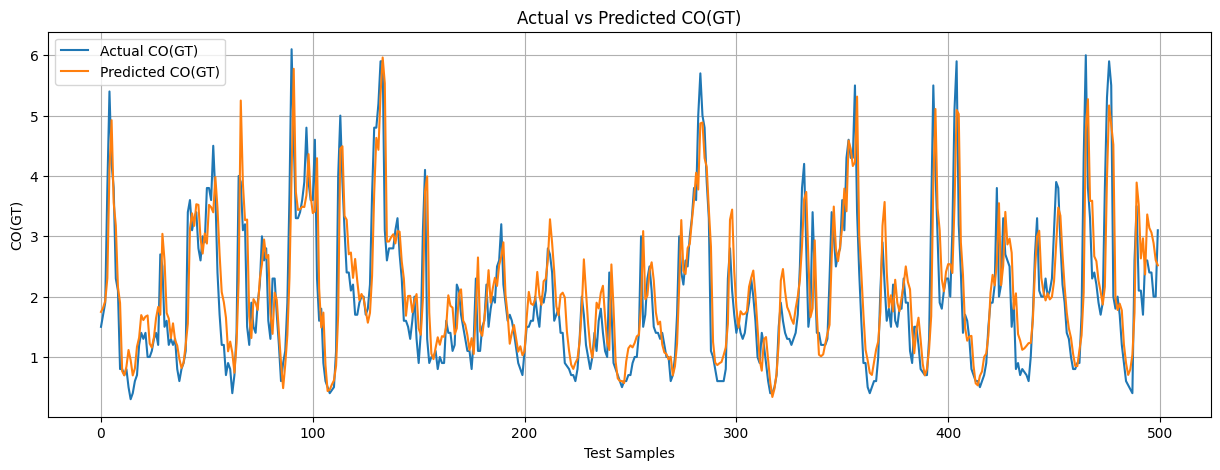

In [63]:
plt.figure(figsize=(15, 5))

plt.plot(
    y_test_original[:500],
    label='Actual CO(GT)'
)

plt.plot(
    y_pred_original[:500],
    label='Predicted CO(GT)'
)

plt.title('Actual vs Predicted CO(GT)')
plt.xlabel('Test Samples')
plt.ylabel('CO(GT)')

plt.legend()
plt.grid()

plt.show()

In [64]:
results_df = pd.DataFrame({
    'Actual CO(GT)': y_test_original.flatten(),
    'Predicted CO(GT)': y_pred_original.flatten()
})

results_df['Absolute Error'] = (
    results_df['Actual CO(GT)']
    -
    results_df['Predicted CO(GT)']
).abs()

results_df.head(10)

,Actual CO(GT),Predicted CO(GT),Absolute Error
0,1.5,1.746895,0.246895
1,1.7,1.816154,0.116154
2,1.9,1.927825,0.027825
3,3.8,2.306087,1.493913
4,5.4,4.101562,1.298438
5,4.2,4.923808,0.723808
6,3.8,3.554375,0.245625
7,2.3,3.178275,0.878275
8,2.1,2.157916,0.057916
9,0.8,1.895591,1.095591
